In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import SimpleITK as sitk
import templateflow.api as tflow

In [2]:
pd.options.display.max_colwidth = 100

## Load results

In [3]:
OUTPUT_DIR = Path("output")

records = []
for jsonl in OUTPUT_DIR.glob("*/results.jsonl"):
    records.extend(pd.read_json(jsonl, lines=True).to_dict("records"))

df = pd.DataFrame(records)


# Parse stop condition into convergence type and iteration count
def parse_stop_cond(s):
    m = re.search(r"Convergence checker passed at iteration (\d+)", s)
    if m:
        return "converged", int(m.group(1))
    m = re.search(r"Maximum number of iterations \((\d+)\)", s)
    if m:
        return "max_iter", int(m.group(1))
    return "unknown", None


df[["stop_type", "n_iter"]] = df["stop_cond"].apply(parse_stop_cond).apply(pd.Series)
df["input"] = df["input"].apply(lambda p: Path(p).name)
df["final_metric"] = -df["final_metric"]

print("\nFinal metric:")
print(df.groupby("version")["final_metric"].describe().round(3))
print("\nRun time:")
print(df.groupby("version")["run_time"].describe().round(3))
print("\nStop type counts:")
print(df.groupby(["version", "stop_type"]).size())


Final metric:
         count   mean    std    min    25%    50%    75%    max
version                                                        
v1        64.0  0.364  0.084  0.100  0.327  0.382  0.411  0.522
v2        31.0  0.406  0.048  0.304  0.380  0.400  0.433  0.507
v3        64.0  0.343  0.103  0.091  0.307  0.368  0.413  0.507
v4        27.0  0.069  0.025  0.036  0.045  0.072  0.082  0.127

Run time:
         count    mean    std    min     25%     50%     75%     max
version                                                             
v1        64.0  13.144  6.211  7.266  10.750  11.666  12.460  39.012
v2        31.0  21.998  4.751  8.816  20.966  23.381  23.936  32.223
v3        64.0   7.214  2.925  4.225   5.649   5.996   7.610  15.404
v4        27.0   3.523  1.004  2.280   3.278   3.435   3.506   8.212

Stop type counts:
version  stop_type
v1       converged    62
         max_iter      2
v2       converged    31
v3       converged    64
v4       converged    27
dtype: int64


## Histograms

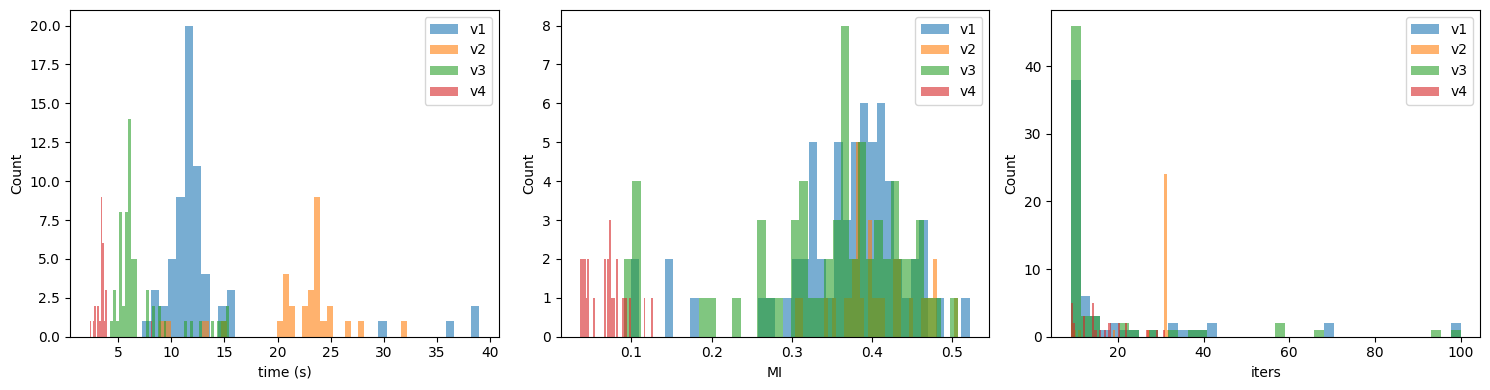

In [4]:
versions = sorted(df["version"].unique())
metrics = [
    ("run_time", "time (s)"),
    ("final_metric", "MI"),
    ("n_iter", "iters"),
]

fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4))

for ax, (col, label) in zip(axes, metrics):
    for version in versions:
        vals = df.loc[df["version"] == version, col].dropna()
        ax.hist(vals, bins=40, alpha=0.6, label=version)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend()

fig.tight_layout()

## Image grid — axial middle slice with template outline

In [5]:
template_mask_path = tflow.get(
    "MNI152NLin6Asym", desc="brain", resolution=1, suffix="mask", extension="nii.gz"
)
template_mask = sitk.GetArrayFromImage(sitk.ReadImage(str(template_mask_path)))  # (Z, Y, X)
mid_z = template_mask.shape[0] // 2
template_mask_slice = template_mask[mid_z]

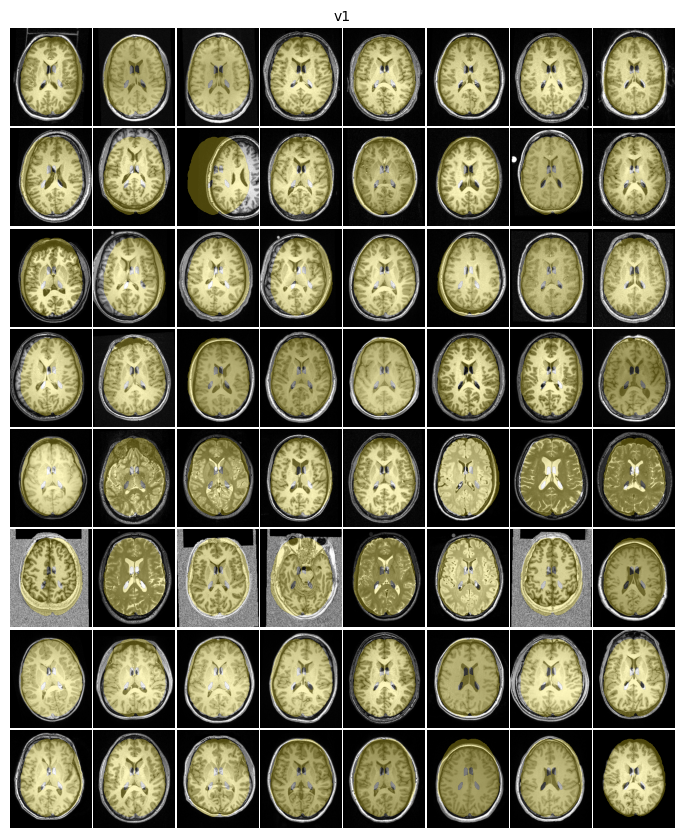

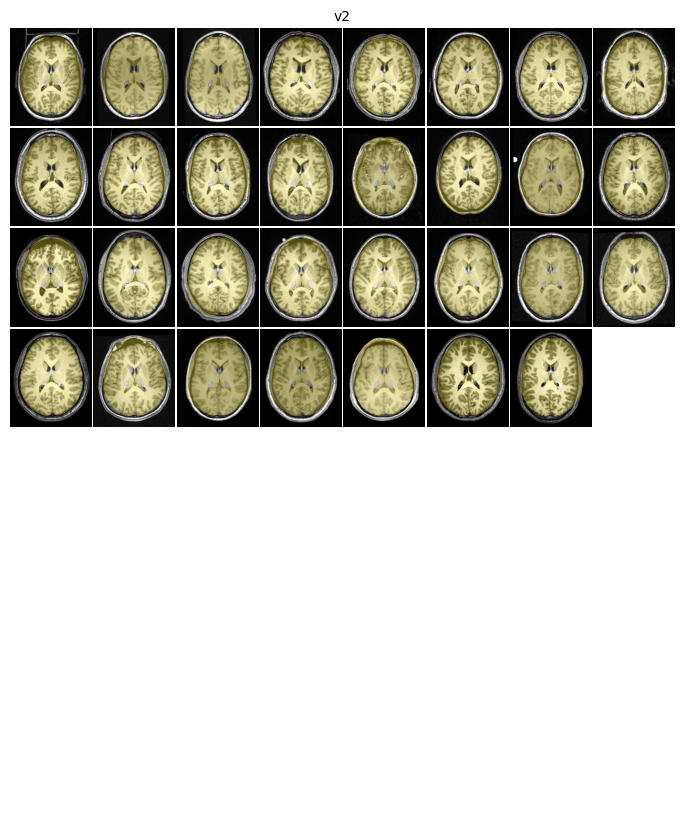

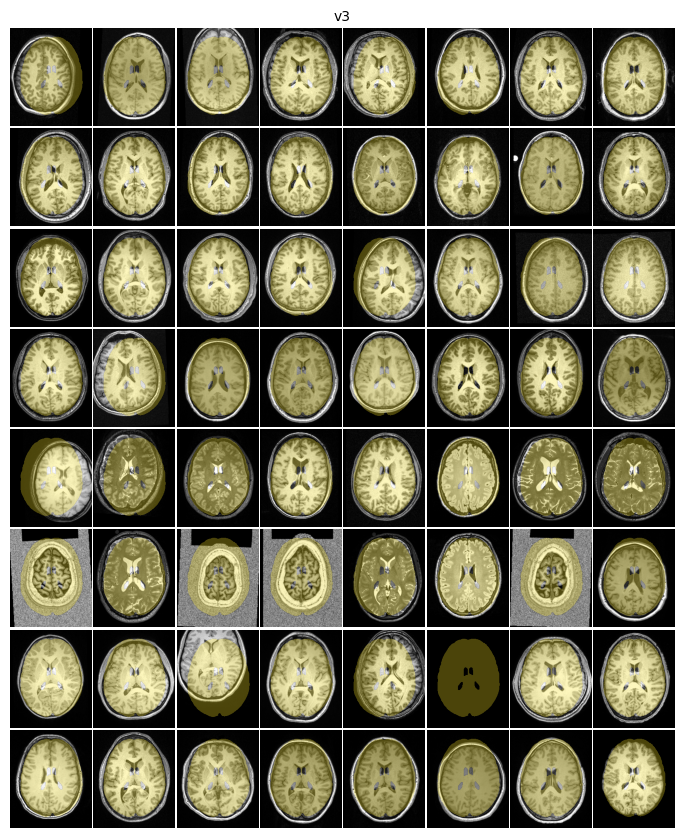

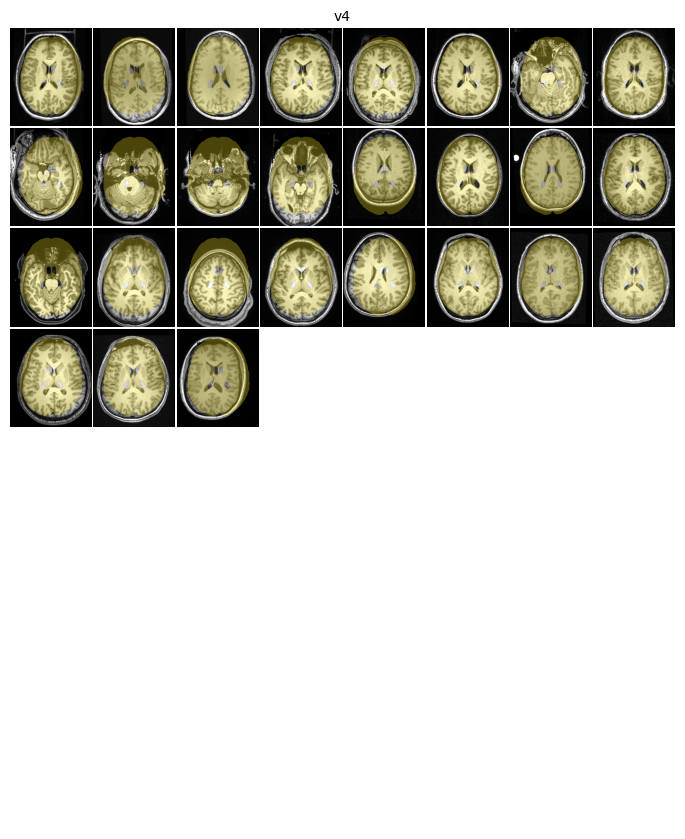

In [6]:
def image_grid(version, nrow: int = 8, ncol: int = 8):
    img_paths = sorted((OUTPUT_DIR / version).glob("*.nii*"))
    img_paths = img_paths[: nrow * ncol]
    H, W = template_mask_slice.shape
    ploth = 1.0
    plotw = (W / H) * ploth
    padh = 0.2

    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * plotw, nrow * ploth + padh))
    axes = axes.ravel()

    for ii, ax in enumerate(axes):
        if ii >= len(img_paths):
            ax.axis("off")
            continue
        path = img_paths[ii]
        arr = sitk.GetArrayFromImage(sitk.ReadImage(str(path)))
        sl = arr[mid_z]
        vmax = np.percentile(sl, 99)
        ax.imshow(sl, cmap="gray", vmin=0, vmax=vmax, origin="lower")
        ax.imshow(
            np.where(template_mask_slice > 0, 1.0, np.nan), vmin=0.0, alpha=0.3, origin="lower"
        )
        ax.axis("off")

    fig.suptitle(version, y=1.001, fontsize=10)
    fig.tight_layout(pad=0.1)


for version in versions:
    image_grid(version)

In [7]:
df.loc[df["version"] == "v1"].sort_values("final_metric").loc[:, ["input", "final_metric"]].head(10)

,input,final_metric
43,ds000221__sub-010198_ses-02_acq-mp2rage_T1w.nii.gz,0.099588
10,ds000030__sub-70081_T1w.nii.gz,0.101214
46,ds000221__sub-010297_ses-01_acq-mp2rage_T1w.nii.gz,0.149384
40,ds000221__sub-010136_ses-01_acq-mp2rage_T1w.nii.gz,0.151897
42,ds000221__sub-010163_ses-01_acq-mp2rage_T1w.nii.gz,0.183829
63,ds001110__sub-37_run-1_T1w.nii.gz,0.267533
17,ds000115__sub-02_T1w.nii.gz,0.277963
9,ds000030__sub-70010_T1w.nii.gz,0.290006
19,ds000115__sub-79_T1w.nii.gz,0.308157
13,ds000102__sub-22_T1w.nii.gz,0.309691
